# Simple Weather Prediction
This is a super simple predicting model of weather in New York. This model is only a **baseline model**, this is just a simple practice on how to build a predicting model.

- The initial training and testing dataset is collected from an archive api, between 2023 and 2025.

- The second evaluation used a dataset of the same location between 01/01/2026 to 07/31/2026.



## Setup

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import train_test_split

In [29]:
import seaborn as sns

## Collect Data

In [20]:
import pandas as pd
import requests

# 1. API Endpoint and Parameters (No API key needed)
url = "https://archive-api.open-meteo.com/v1/archive"
params = {
    "latitude": 40.7128,  # New York City
    "longitude": -74.0060,
    "start_date": "2023-01-01",
    "end_date": "2025-12-31",
    "daily": "temperature_2m_max",
    "timezone": "America/New_York",
}

# 2. Fetch data
response = requests.get(url, params=params)
data = response.json()

# 3. Convert JSON response to Pandas DataFrame
df = pd.DataFrame(
    {
        "date": data["daily"]["time"],
        "temp_max": data["daily"]["temperature_2m_max"],
    }
)

print(df.head())

         date  temp_max
0  2023-01-01      12.0
1  2023-01-02      12.9
2  2023-01-03      12.9
3  2023-01-04      18.0
4  2023-01-05      13.2


In [32]:
df1=df.copy()

# month
df1['month'] = pd.to_datetime(df1['date']).dt.month

# year
df1['year'] = pd.to_datetime(df1['date']).dt.year

<Axes: xlabel='year', ylabel='temp_max'>

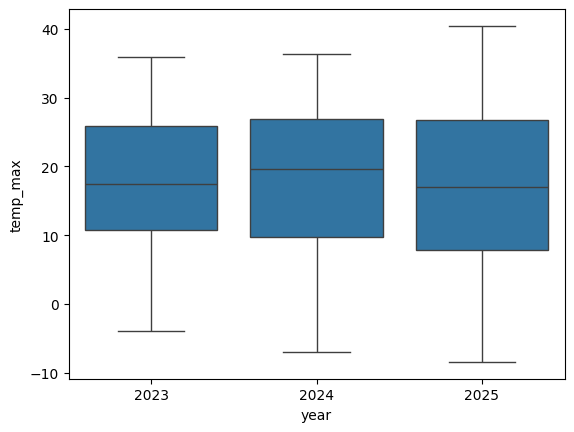

In [36]:
# temp_max distribution annually
sns.boxplot(x='year', y='temp_max', data=df1)

## Preparing Variables

In [21]:
# Feature (X): Today's max temperature
df["today_temp"] = df["temp_max"]

# Target (y): Tomorrow's max temperature (Shifted backwards by 1 day)
df["tomorrow_temp"] = df["temp_max"].shift(-1)

# Drop the last row because tomorrow's temperature is unknown (NaN)
df = df.dropna()

X = df[["today_temp"]]  # Features DataFrame
y = df["tomorrow_temp"]  # Target Series

In [22]:
df[["today_temp", "tomorrow_temp"]]

,today_temp,tomorrow_temp
0,12.0,12.9
1,12.9,12.9
2,12.9,18.0
3,18.0,13.2
4,13.2,8.7
...,...,...
1090,-2.7,-1.0
1091,-1.0,1.1
1092,1.1,7.4
1093,7.4,-0.3


## Build Predicting Model

In [27]:
# 1. Split into Train (80%) and Test (20%) sets without shuffling
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, shuffle=False
)

# 2. Initialize and train model
model = LinearRegression()
model.fit(X_train, y_train)

# 3. Make predictions on unseen test data
y_pred = model.predict(X_test)

# 4. Evaluate results
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Mean Squared Error: {mse:.2f}")
print(f"R-squared Score: {r2:.2f}")

Mean Squared Error: 14.11
R-squared Score: 0.87


In [26]:
# Predict tomorrow if today's max temp is 25°C
sample_input = pd.DataFrame({"today_temp": [25.0]})
predicted_temp = model.predict(sample_input)

print(
    f"If today is 25°C, predicted max temp for tomorrow is: {predicted_temp[0]:.2f}°C"
)

If today is 25°C, predicted max temp for tomorrow is: 24.31°C


## Testing on dataset of 2026

### Collecting weather data of 2026

The daily weather data is from 01/01/2026 to 07/31/2026 in New York

In [12]:
params_2026 = {
    "latitude": 40.7128,  # New York City
    "longitude": -74.0060,
    "start_date": "2026-01-01",
    "end_date": "2026-07-31",
    "daily": "temperature_2m_max",
    "timezone": "America/New_York",
}

response_2026 = requests.get(url, params=params_2026)
data = response_2026.json()

# 3. Convert JSON response to Pandas DataFrame
test_2026 = pd.DataFrame(
    {
        "date": data["daily"]["time"],
        "temp_max": data["daily"]["temperature_2m_max"],
    }
)

In [23]:
test_2026_v2 = test_2026.copy() # backup

### Preparing Dataset
- Feature and Target variables
- Training and Testing dataset

In [24]:
# Feature (X): Today's max temperature
test_2026["today_temp"] = test_2026["temp_max"]

# Target (y): Tomorrow's max temperature (Shifted backwards by 1 day)
test_2026["tomorrow_temp"] = test_2026["temp_max"].shift(-1)

# Drop the last row because tomorrow's temperature is unknown (NaN)
test_2026 = test_2026.dropna()

X_2026 = test_2026[["today_temp"]]  # Features DataFrame
y_2026 = test_2026["tomorrow_temp"]  # Target Series


In [25]:
y_2026_pred = model.predict(X_2026) # have the model predict the weather

## evaluating against actual data
mse = mean_squared_error(y_2026, y_2026_pred)

r2 = r2_score(y_2026, y_2026_pred)

print(f"Mean Squared Error: {mse:.2f}")
print(f"R-squared Score: {r2:.2f}")

Mean Squared Error: 20.76
R-squared Score: 0.87


<Axes: xlabel='today_temp', ylabel='tomorrow_temp'>

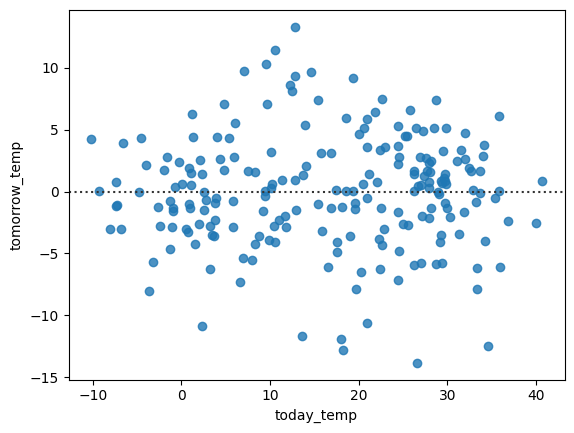

In [40]:
sns.residplot(x=X_2026, y=y_2026)